In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define sizes
Bsizerates = [0,1,2] 
Elsizes = [500] 
Ssizes = [200,400,600,800]
Psizerates = [2,4,6]


# Define parameters
electrolyzer_efficiency = 62.7  # % based on 66% LLH H2 coressponds to 50.45 + 2.7 kWh for compressor = 53.15 corresponds to 62.7%
Csize = 8  # Compressor capacity in kg H2/hour
Initial_storage_status = 200

# Load PV hourly data
PV = pd.read_csv("PVhourlyHydrogen500.csv", delimiter=";")
PriceAllYears = pd.read_csv("PriceAllYears.csv", delimiter=";")

# Initialize economic results dataframe
economic_df = pd.DataFrame()

# Loop over all parameter combinations
for Psizerate in Psizerates:
    for Bsizerate in Bsizerates:
        for Esize in Elsizes:
            for Ssize in Ssizes:
                #Setting the pv size to be double the electrolyzer
                Psize = Psizerate * Esize
                Bsize = Esize * Bsizerate
                # Initialize lists           
                battery_status = [0]  
                excess_energy = []
                electrolyzer_production = []
                pv_to_electrolyzer = []  
                storage_status = [Initial_storage_status]
                compressor_flow_list = []  
                grid_to_electrolyzer = []  # Track Grid input
    
    
                
                # Create simulation dataframe
                Simh = PV[['Year', 'Month', 'Day', 'Hour', 'Production (Wh)', 'Consumption (kWh H2']].copy()
                # Calculate PV production in kWh
                Simh['PV production (kWh)'] = (Simh['Production (Wh)'] / 1000) * Psize
                Simh['Consumption (kg H2)'] = Simh['Consumption (kWh H2']/33.3
                # Load electricity prices
                Simh = Simh.merge(PriceAllYears, on=['Year', 'Month', 'Day', 'Hour'], how='left')  
                
                # Define grid-to-electrolyzer conditions
                price_threshold = 0 # Simh['N4 (EUR/kWh)'].quantile(0.8)  # 20th percentile
                storage_threshold = 0.9 * Ssize 
                for i in range(len(Simh)):
                    prev_battery = battery_status[-1] if i > 0 else 0  
                    prev_storage = storage_status[-1] if i > 0 else Initial_storage_status  
                
                    # Available PV energy
                    pv_production = Simh.loc[i, 'PV production (kWh)']
                
                    # Condition to stop PV to Electrolyzer
                    if (i > 0 and compressor_flow_list[-1] >= Csize) or (prev_storage >= Ssize-Csize):
                        pv_to_el = 0  
                        excess_e = pv_production  
                    else:
                        pv_to_el = min(pv_production, Esize)  
                        excess_e = max(0, pv_production - pv_to_el)  


                    excess_e1 = excess_e
                    # Battery charging
                    charged_battery = min(Bsize, max(0, prev_battery + excess_e1))
                    battery_charge_added = charged_battery - prev_battery
                    excess_e = max(0, excess_e1 - battery_charge_added)  
                    
                    # Grid to Electrolyzer logic
                    current_price = Simh.loc[i, 'N4 (EUR/kWh)']
                    #current_storage = storage_status[-1]
                
                   # if current_price < price_threshold and prev_storage < min(storage_threshold,Ssize-Csize):
                   #     h2_needed = max(storage_threshold - prev_storage, Esize/(33.3 / (electrolyzer_efficiency / 100)))
                   #     energy_needed = h2_needed * 33.3 / (electrolyzer_efficiency / 100)  
                   #     grid_input = min(energy_needed-pv_to_el, Esize-pv_to_el)  
                   # else:
                   #     grid_input = 0
                   # grid_to_electrolyzer.append(grid_input)
                
                   
                     # Step 1: Calculate how much more energy the electrolyzer can accept
                    remaining_el_capacity = Esize - pv_to_el
                    # Step 2: Use battery energy next
                    battery_used = 0
                    if remaining_el_capacity>0 and prev_storage < (Ssize - Csize):
                        battery_used = min(charged_battery, remaining_el_capacity)
                    new_battery = max(0,charged_battery - battery_used)
                    # Step 3: If still under capacity, use grid (if conditions allow)
                    grid_input = 0
                    if remaining_el_capacity - battery_used > 0 and current_price < price_threshold and prev_storage < min(storage_threshold, Ssize - Csize):
                        grid_input = remaining_el_capacity - battery_used
                    
                    # Total energy for electrolyzer
                    available_energy = pv_to_el + battery_used + grid_input
                    
                    grid_to_electrolyzer.append(grid_input)
                    
                    electrolyzer_energy = min(available_energy, Esize)
                
                    # Update battery after electrolyzer consumption
                    #new_battery -= max(0, Esize - pv_to_el - grid_input)
                    #new_battery = max(0, new_battery)  
                
                    # Hydrogen production calculation
                    h2_produced = electrolyzer_energy * (electrolyzer_efficiency / 100) * (1 / 33.3)
                    compressor_flow = min(h2_produced, Csize)  
                    compressor_flow_list.append(compressor_flow)  
                
                    # Update H2 storage
                    new_storage = min(Ssize, max(0, prev_storage + compressor_flow - Simh.loc[i, 'Consumption (kg H2)']))
                    storage_status.append(new_storage)  
                
                    # Store results
                    battery_status.append(new_battery)
                    excess_energy.append(excess_e)
                    electrolyzer_production.append(electrolyzer_energy)
                    pv_to_electrolyzer.append(pv_to_el)
                
                # Add computed values to DataFrame
                Simh['Battery status (kWh)'] = battery_status[1:]
                Simh['Excess e (kWh)'] = excess_energy
                Simh['Electrolyzer production (kWh)'] = electrolyzer_production
                Simh['PV to Electrolyzer (kWh)'] = pv_to_electrolyzer
                Simh['Grid to Electrolyzer (kWh)'] = grid_to_electrolyzer  # Add Grid input
                Simh['Hydrogen produced (kg)'] = Simh['Electrolyzer production (kWh)'] * electrolyzer_efficiency / 100 * (1 / 33.3)
                Simh['Compressor flow (kg H2)'] = compressor_flow_list  
                Simh['H2 storage (kg H2)'] = storage_status[1:]  
                
                # Initialize H2def list
                H2def = [0]  
                
                for i in range(1, len(Simh)):  
                    prev_storage = Simh.loc[i - 1, 'H2 storage (kg H2)']
                    current_storage = Simh.loc[i, 'H2 storage (kg H2)']
                    consumption = Simh.loc[i, 'Consumption (kg H2)']
                    compressor_flow = Simh.loc[i, 'Compressor flow (kg H2)']
                
                    h2_consumed = max(0, prev_storage - current_storage + compressor_flow)
                    deficit = max(0, consumption - h2_consumed)
                
                    H2def.append(deficit)
                
                Simh['H2def (kg H2)'] = H2def
                
                # Save updated dataframe
                Simh.to_csv("Simh.csv", index=False, sep=";")
                
            
                
                
                # Preparing the economical results              
                # Economic Parameters
                Discount_Rate = 0.05  
                Lifetime = 30  # Project lifetime in years
                
                # CAPEX and OPEX Definitions
                H2_Storage_Capex = 1100 * Ssize  # EUR/kg H2
                H2_Storage_Lifetime = 30  # years
                Annual_H2_Storage_Opex = 1 * H2_Storage_Capex / 100  # % of CAPEX per year
                
                Battery_Capex = 800 * Bsize  # EUR/kWh
                Battery_Lifetime = 30  # years (doubled from original 15 * 2)
                Annual_Battery_Opex = 2 * Battery_Capex / 100 # % of CAPEX per year
                
                Compressor_Capex = 240000  # EUR per unit
                Compressor_Lifetime = 30  # years
                Annual_Compressor_Opex = 0.5 * Compressor_Capex / 100  # % of CAPEX per year
                
                PV_Capex = 900 * Psize  # EUR/kWp
                PV_Lifetime = 30  # years
                Annual_PV_Opex = 1.5 * PV_Capex / 100 # % of CAPEX per year
                
                Electrolyzer_Lifetime = 30  # years
                # Electrolyzer CAPEX Calculation (based on size)
                Electrolyzer_Capex_unit = 1.1195 * (585.85 + (Esize ** 0.622) * (9485.2 / Esize))
                Electrolyzer_CAPEX = Esize * Electrolyzer_Capex_unit
                Annual_Electrolyzer_Opex = 2 * Electrolyzer_CAPEX / 100 # % of CAPEX per year
                Electrolyzer_Replacement_Cost = 0.35 * Electrolyzer_CAPEX  # 35% of initial CAPEX per replacement
                Electrolyzer_Water_Consumption = 10 #liter per kg H2
                Water_Cost = 0.00053  #EUR/liter 
                
                #N3T electricity fee
                Monthly_N3T_Fixed_Fee = 359 # EUR2024/month calculated from 4100 kr per month
                Monthly_N3T_Power_Fee = 3 * Esize # Given in EUR2024/month calculated from 34 kr/kw
                Monthly_N3T_HighLoad_Fee = 7.5 * Esize # Given in EUR2024/month calculated from 86 kr/kw
                Annual_N3T_Electricity_Fixed_Cost =0* 12 * (Monthly_N3T_Fixed_Fee + Monthly_N3T_Power_Fee + Monthly_N3T_HighLoad_Fee)
                
                #N4 electricity fee
                Monthly_N4_Fixed_Fee = 42 # EUR2024/month calculated from 480 kr per month
                Monthly_N4_Power_Fee = 4.1 * Esize # Given in EUR2024/month calculated from 47 kr/kw
                Monthly_N4_HighLoad_Fee = 0 * Esize # Given in EUR2024/month calculated from 0 kr/kw
                Annual_N4_Electricity_Fixed_Cost =0* 12 * (Monthly_N4_Fixed_Fee + Monthly_N4_Power_Fee + Monthly_N4_HighLoad_Fee)
                
                
                
                # Total CAPEX
                Total_CAPEX = PV_Capex + Battery_Capex + Electrolyzer_CAPEX + H2_Storage_Capex + Compressor_Capex
                
                
                
                # OPEXfix is the fixed annual operating expenditure
                Total_annual_OPEX_fix = Annual_Electrolyzer_Opex + Annual_PV_Opex + Annual_Compressor_Opex + Annual_Battery_Opex + Annual_H2_Storage_Opex + Annual_N4_Electricity_Fixed_Cost
                
                # Discounting OPEX over the lifetime
                Total_Discounted_OPEX_fix = Total_annual_OPEX_fix * sum([1 / (1 + Discount_Rate) ** t for t in range(1, Lifetime + 1)])
                
                
                # OPEXvar is the variable annual operating expenditure (grid electricity and water for the electrolyser)
                Total_Discounted_Replacement_Cost = Electrolyzer_Replacement_Cost / (1 + Discount_Rate) ** 10 + Electrolyzer_Replacement_Cost / (1 + Discount_Rate) ** 20
                
                # Calculate total electricity cost from grid usage
                Simh['Electricity Cost (EUR)'] = 0 * Simh['Grid to Electrolyzer (kWh)'] * Simh['N4 (EUR/kWh)']
                Total_Electricity_Cost = Simh['Electricity Cost (EUR)'].sum()
                # Calculate total income from selling excess electricity
                Simh['Electricity Income (EUR)'] = 0* Simh['Excess e (kWh)'] * Simh['Income (EUR/kWh)']
                Total_Electricity_Income = 0* Simh['Electricity Income (EUR)'].sum()
                # Divide by 14 for average annual values
                Annual_Electricity_Cost = 0* Total_Electricity_Cost / 14
                Annual_Electricity_Income = 0* Total_Electricity_Income / 14
                Total_Discounted_Electricity_Cost = 0*Annual_Electricity_Cost * sum([1 / (1 + Discount_Rate) ** t for t in range(1, Lifetime + 1)])
                Total_Discounted_Electricity_Income = 0*Annual_Electricity_Income * sum([1 / (1 + Discount_Rate) ** t for t in range(1, Lifetime + 1)])
                
                # Water cost 
                Annual_H2_Produced = Simh['Hydrogen produced (kg)'].sum()/14  # Total H2 produced over the simulation
                Annual_Water_Cost = Electrolyzer_Water_Consumption * Water_Cost * Annual_H2_Produced
                Total_Discounted_Water_Cost = Annual_Water_Cost * sum([1 / (1 + Discount_Rate) ** t for t in range(1, Lifetime + 1)])
                
                
                
                Total_CAPEX
                Total_Discounted_OPEX_fix
                Total_Discounted_Replacement_Cost
                Total_Discounted_Electricity_Cost
                Total_Discounted_Water_Cost
                Total_Discounted_Electricity_Income
                
                # Levelized Cost of Hydrogen (LCOH) 
                Total_H2_Produced = Lifetime * Annual_H2_Produced
                Net_Present_Cost= Total_CAPEX + Total_Discounted_OPEX_fix + Total_Discounted_Replacement_Cost + Total_Discounted_Electricity_Cost + Total_Discounted_Water_Cost -Total_Discounted_Electricity_Income
                if Total_H2_Produced > 0:
                    LCOH = (Net_Present_Cost) / Total_H2_Produced
                else:
                    LCOH = np.nan  # Avoid division by zero
                
                
                economic_results = {
                    'Discount Rate': [Discount_Rate],
                    'Battery Size (kWh)': [Bsize],
                    'Electrolyzer Size (kWp)': [Esize],
                    'Storage Size (kg H2)': [Ssize],
                    'PV Size (kWp)': [Psize],
                    'LCOH (EUR2024/kg H2)': [LCOH],
                    'Net Present Cost (EUR2024)': [Net_Present_Cost], 
                    'Total CAPEX (EUR2024)': [Total_CAPEX],
                    'PV Capex':PV_Capex,
                    'Battery Capex':Battery_Capex,
                    'Electrolyzer Capex':Electrolyzer_CAPEX,
                    'H2 Storage Capex':H2_Storage_Capex,
                    'Compressor Capex':Compressor_Capex,
                    'Total Discounted Fixed OPEX (EUR2024)': [Total_Discounted_OPEX_fix],
                    'Annual Electrolyzer Opex':Annual_Electrolyzer_Opex,
                    'Annual PV Opex':Annual_PV_Opex,
                    'Annual Compressor Opex':Annual_Compressor_Opex,
                    'Annual Battery Opex':Annual_Battery_Opex,
                    'Annual H2 Storage Opex':Annual_H2_Storage_Opex,
                    'Annual N4 Electricity Fixed Cost':Annual_N4_Electricity_Fixed_Cost,
                    'Total Discounted Replacement Cost (EUR2024)': [Total_Discounted_Replacement_Cost],
                    'Total Discounted Electricity Cost (EUR2024)': [Total_Discounted_Electricity_Cost],
                    'Total Discounted Water Cost (EUR2024)': [Total_Discounted_Water_Cost],
                    'Total Discounted Electricity Income (EUR2024)': [Total_Discounted_Electricity_Income],
                    'Total H2 produced (kg)': [Total_H2_Produced],
                    'Total H2 deficit (kg)': [30*sum(Simh['H2def (kg H2)'])/14],
                    'Electrolyzer usage (%)': [100*(sum(Simh['Electrolyzer production (kWh)'])/14)/(8760*Esize)],
                    'Electrolyzer production (kWh)': [30*sum(Simh['Electrolyzer production (kWh)'])/14], 
                    'PV to Electrolyzer (kWh)': [30*sum(Simh['PV to Electrolyzer (kWh)'])/14], 
                    'Grid to Electrolyzer (kWh)':[30*sum(Simh['Grid to Electrolyzer (kWh)'])/14],
                    'Consumption (kg)': [30*sum(Simh['Consumption (kg H2)'])/14],
                    'PV production (kWh)':[30*sum(Simh['PV production (kWh)'])/14],
                    'Excess electricity':[30*sum(Simh['Excess e (kWh)'])/14]
                }
                economic_df = pd.concat([economic_df, pd.DataFrame([economic_results])], ignore_index=True)

#Save to file
economic_df.to_csv("Island_Operation_economic_results.csv", index=False, sep=";")


In [2]:
economic_df

,Discount Rate,Battery Size (kWh),Electrolyzer Size (kWp),Storage Size (kg H2),PV Size (kWp),LCOH (EUR2024/kg H2),Net Present Cost (EUR2024),Total CAPEX (EUR2024),PV Capex,Battery Capex,...,Total Discounted Electricity Income (EUR2024),Total H2 produced (kg),Total H2 deficit (kg),Electrolyzer usage (%),Electrolyzer production (kWh),PV to Electrolyzer (kWh),Grid to Electrolyzer (kWh),Consumption (kg),PV production (kWh),Excess electricity
0,[0.05],[0],[500],[200],[1000],[32.999319483584316],[3000863.132622128],[2194721.7505363217],900000,0,...,[0.0],[90937.12172200772],[17516.514823713027],[3.6755516634050878],[4829674.885714285],[4829674.885714285],[0.0],[102904.92287004505],[28098587.207142856],[23268912.32142857]
1,[0.05],[0],[500],[400],[1000],[32.34014977500109],[3254708.8756360887],[2414721.7505363217],900000,0,...,[0.0],[100639.88256949806],[8815.65484880958],[4.067723727984345],[5344988.978571429],[5344988.978571429],[0.0],[102904.92287004505],[28098587.207142856],[22753598.228571426]
2,[0.05],[0],[500],[600],[1000],[32.71418547764079],[3508546.2154845516],[2634721.7505363217],900000,0,...,[0.0],[107248.46620077222],[2947.006178925432],[4.334833463796477],[5695971.1714285705],[5695971.1714285705],[0.0],[102904.92287004505],[28098587.207142856],[22402616.035714287]
3,[0.05],[0],[500],[800],[1000],[34.0245461351003],[3762374.650760064],[2854721.7505363217],900000,0,...,[0.0],[110578.24653474905],[150.4419477221217],[4.469418542074364],[5872815.964285715],[5872815.964285715],[0.0],[102904.92287004505],[28098587.207142856],[22225771.24285714]
4,[0.05],[500],[500],[200],[1000],[33.60200161933436],[3523880.582869234],[2594721.7505363217],900000,400000,...,[0.0],[104871.15091505791],[7354.8765669563],[4.2387456947162425],[5569711.842857143],[2781516.771428571],[0.0],[102904.92287004505],[28098587.207142856],[22527803.935714286]
5,[0.05],[500],[500],[400],[1000],[34.01787756539449],[3777716.758155908],[2814721.7505363217],900000,400000,...,[0.0],[111050.92464671815],[1967.7356735908022],[4.488523532289628],[5897919.9214285705],[2973649.3714285716],[0.0],[102904.92287004505],[28098587.207142856],[22199595.85714286]
6,[0.05],[500],[500],[600],[1000],[35.52095393290619],[4031542.795077915],[3034721.7505363217],900000,400000,...,[0.0],[113497.59363706564],[124.71886664102956],[4.587414481409002],[6027862.628571428],[3060458.1214285716],[0.0],[102904.92287004505],[28098587.207142856],[22069653.150000002]
7,[0.05],[500],[500],[800],[1000],[37.56653747799917],[4285363.7526369095],[3254721.7505363217],900000,400000,...,[0.0],[114073.9615714286],[2.2717637295142723e-10],[4.610710469667319],[6058473.557142858],[3068250.128571429],[0.0],[102904.92287004505],[28098587.207142856],[22039042.22142857]
8,[0.05],[1000],[500],[200],[1000],[37.31100584834889],[4046869.9462868427],[2994721.7505363217],900000,800000,...,[0.0],[108463.16935907336],[6018.535254214991],[4.383930071754729],[5760484.114285714],[2440845.492857143],[0.0],[102904.92287004505],[28098587.207142856],[22335960.235714283]
9,[0.05],[1000],[500],[400],[1000],[37.72883900899917],[4300704.347878211],[3214721.7505363217],900000,800000,...,[0.0],[113989.8406853282],[1287.5167411583723],[4.60731042074364],[6054005.892857143],[2621893.007142857],[0.0],[102904.92287004505],[28098587.207142856],[22042438.457142856]


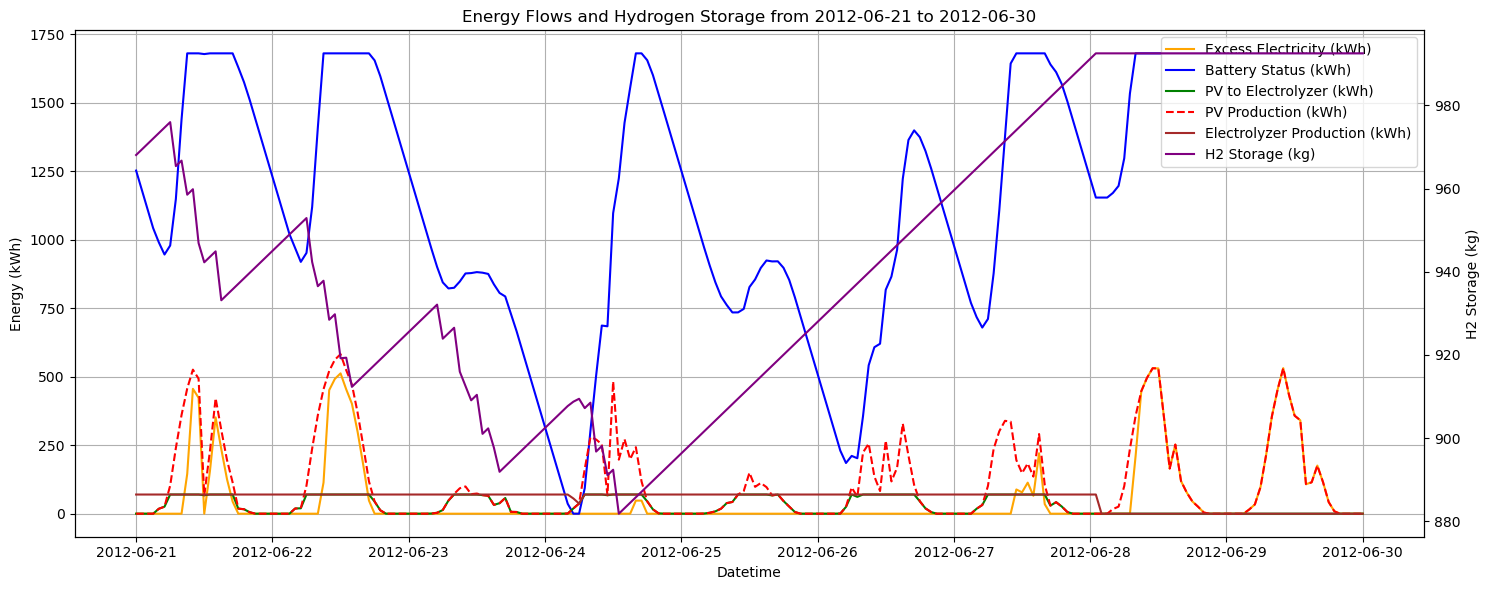

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Simh dataframe
Simh = pd.read_csv("Simh.csv", delimiter=";")

# Create datetime column
Simh['Datetime'] = pd.to_datetime(Simh[['Year', 'Month', 'Day', 'Hour']])

# Define time interval
start_date = "2012-06-21"
end_date = "2012-06-30"

# Filter for selected interval
mask = (Simh['Datetime'] >= start_date) & (Simh['Datetime'] <= end_date)
Simh_interval = Simh.loc[mask]

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot on primary axis
ax1.plot(Simh_interval['Datetime'], Simh_interval['Excess e (kWh)'], label='Excess Electricity (kWh)', color='orange')
ax1.plot(Simh_interval['Datetime'], Simh_interval['Battery status (kWh)'], label='Battery Status (kWh)', color='blue')
ax1.plot(Simh_interval['Datetime'], Simh_interval['PV to Electrolyzer (kWh)'], label='PV to Electrolyzer (kWh)', color='green')
ax1.plot(Simh_interval['Datetime'], Simh_interval['PV production (kWh)'], label='PV Production (kWh)', color='red', linestyle='--')
ax1.plot(Simh_interval['Datetime'], Simh_interval['Electrolyzer production (kWh)'], label='Electrolyzer Production (kWh)', color='brown')

ax1.set_xlabel("Datetime")
ax1.set_ylabel("Energy (kWh)")
ax1.grid(True)

# Create a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(Simh_interval['Datetime'], Simh_interval['H2 storage (kg H2)'], label='H2 Storage (kg)', color='purple')
ax2.set_ylabel("H2 Storage (kg)")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title(f"Energy Flows and Hydrogen Storage from {start_date} to {end_date}")
plt.tight_layout()
plt.show()